# Step 1: Import Required Libraries

In this step, we import all the libraries required for data analysis, preprocessing, clustering, visualization, and evaluation.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Step 2: Load the Dataset

In this step, we load the dataset into a pandas DataFrame and display the first few rows to verify that it has been loaded correctly.

In [2]:
df = pd.read_csv("Country-data.csv")

# Display the first 5 rows
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


# Step 3: Explore the Dataset

In this step, we examine the structure of the dataset by checking its dimensions, data types, summary statistics, and missing values.

In [3]:
print("Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nInfo:")
df.info()

print("\nSummary Statistics:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

Shape:
(167, 10)

Columns:
Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB

Summary Statistics:
       child_mort     exports      health     imports         income  \
count  167.000000  167.000000  167.000000  167.000000     167

# Step 4: Data Cleaning

Clean the dataset by removing extra spaces, duplicates, converting data types, and filling missing values.

In [4]:
df.columns = df.columns.str.strip()


df.drop_duplicates(inplace=True)


for col in df.columns[1:]:
    df[col] = pd.to_numeric(df[col], errors='coerce')


df.fillna(df.median(numeric_only=True), inplace=True)

print(df.isnull().sum())

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


# Step 5: Feature Selection and Scaling

Remove the country name column and standardize the numerical features using StandardScaler.

In [5]:
countries = df['country']

X = df.drop('country', axis=1)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Step 6: Determine the Optimal Number of Clusters

Use the Elbow Method to identify the optimal number of clusters for K-Means.

In [6]:
inertia = []

for k in range(2,11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

d:\kashish Btech\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\kashish Btech\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\kashish Btech\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\kashish Btech\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak o

# Step 7: Elbow Method Visualization

Plot the inertia values to identify the optimal number of clusters.

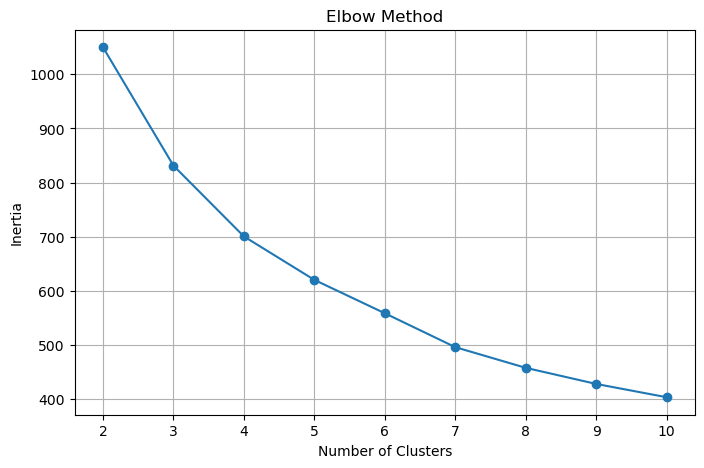

In [7]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11), inertia, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.grid(True)

plt.show()

# Step 8: Train the K-Means Model

Train the K-Means clustering model using the selected number of clusters.

In [8]:
best_k = 3

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

df.head()

d:\kashish Btech\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2


# Step 9: Evaluate the Clustering Model

Evaluate the quality of the K-Means clustering using the Silhouette Score.

In [9]:
score = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.28329575683463126


# Step 10: Apply DBSCAN Clustering

Build a DBSCAN clustering model to compare its results with the K-Means model.

In [10]:
dbscan = DBSCAN(eps=1.5, min_samples=5)

db_clusters = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = db_clusters

df["DBSCAN_Cluster"].value_counts()

DBSCAN_Cluster
 0    137
-1     30
Name: count, dtype: int64

# Step 11: Perform PCA

Reduce the dataset to two principal components for visualization.

In [11]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

X_pca[:5]

array([[-2.91302459,  0.09562058],
       [ 0.42991133, -0.58815567],
       [-0.28522508, -0.45517441],
       [-2.93242265,  1.69555507],
       [ 1.03357587,  0.13665871]])

# Step 12: Visualize the Clusters

Display the K-Means clusters using a two-dimensional PCA scatter plot.

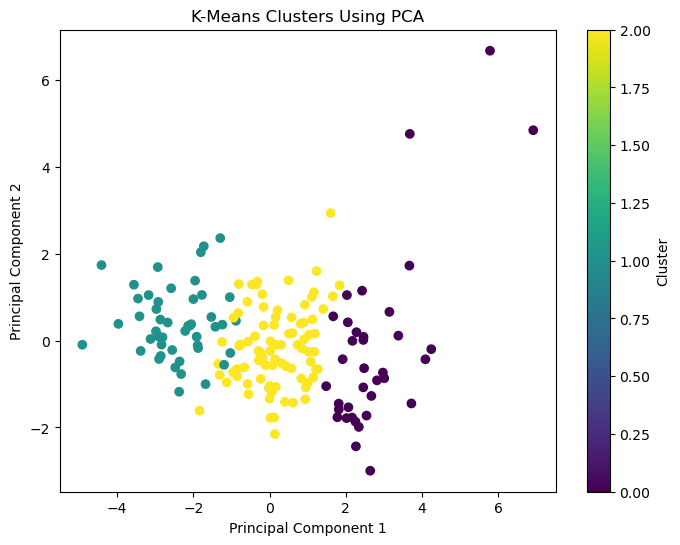

In [12]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="viridis"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters Using PCA")

plt.colorbar(label="Cluster")

plt.show()

# Step 13: Analyze the Clusters

Calculate the average values of each feature for every cluster.

In [13]:
cluster_summary = df.groupby("Cluster").mean(numeric_only=True)

cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,DBSCAN_Cluster
Cluster,,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444,-0.250000
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979,-0.340426
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381,-0.059524


# Step 14: Observations

### Observation 1
Cluster 1 represents the least developed countries, with the highest child mortality (92.96), lowest average income (3942), lowest GDP per capita (1922), and the lowest life expectancy (59.19 years).

### Observation 2
Cluster 0 represents the most developed countries, with the highest average income (45672), highest GDP per capita (42494), highest life expectancy (80.13 years), and the lowest child mortality (5.00).

### Observation 3
Cluster 2 consists of developing countries with moderate socio-economic indicators, including an average income of 12305, GDP per capita of 6486, and life expectancy of 72.81 years.

### Observation 4
The Silhouette Score of 0.2833 indicates a reasonable clustering structure, suggesting that countries are grouped into meaningful socio-economic segments.

### Observation 5
The PCA visualization shows three distinct clusters, demonstrating that K-Means effectively separates countries based on economic and health-related indicators.

# Conclusion

This project successfully applied K-Means and DBSCAN clustering techniques to segment countries based on socio-economic indicators. The Elbow Method identified three optimal clusters, and the Silhouette Score of 0.2833 indicated a reasonable clustering structure. PCA visualization clearly illustrated the separation between clusters, providing meaningful insights into different levels of economic development and social well-being.